In [1]:
!pip install -q openpyxl accelerate datasets transformers

📂 Loading data...

🚀 Starting 5-Fold CV Baseline Testing...

--- FOLD 1 ---

--- FOLD 2 ---

--- FOLD 3 ---

--- FOLD 4 ---

--- FOLD 5 ---

🏆 FINAL BASELINE CV RESULTS (5-Fold Averages)
Model                     | Accuracy   | Precision  | Recall     | F1-Score  
----------------------------------------------------------------------
Naive Bayes               | 0.6510     | 0.6507     | 0.6510     | 0.6472    
Logistic Regression       | 0.6482     | 0.6468     | 0.6482     | 0.6466    
Linear SVM                | 0.6446     | 0.6411     | 0.6446     | 0.6420    
Random Forest             | 0.6324     | 0.6368     | 0.6324     | 0.6309    
MLP (Neural Net)          | 0.6392     | 0.6343     | 0.6392     | 0.6340    

✅ Results saved to 'baseline_comparison.csv'
✅ Chart saved to 'baseline_chart.png'


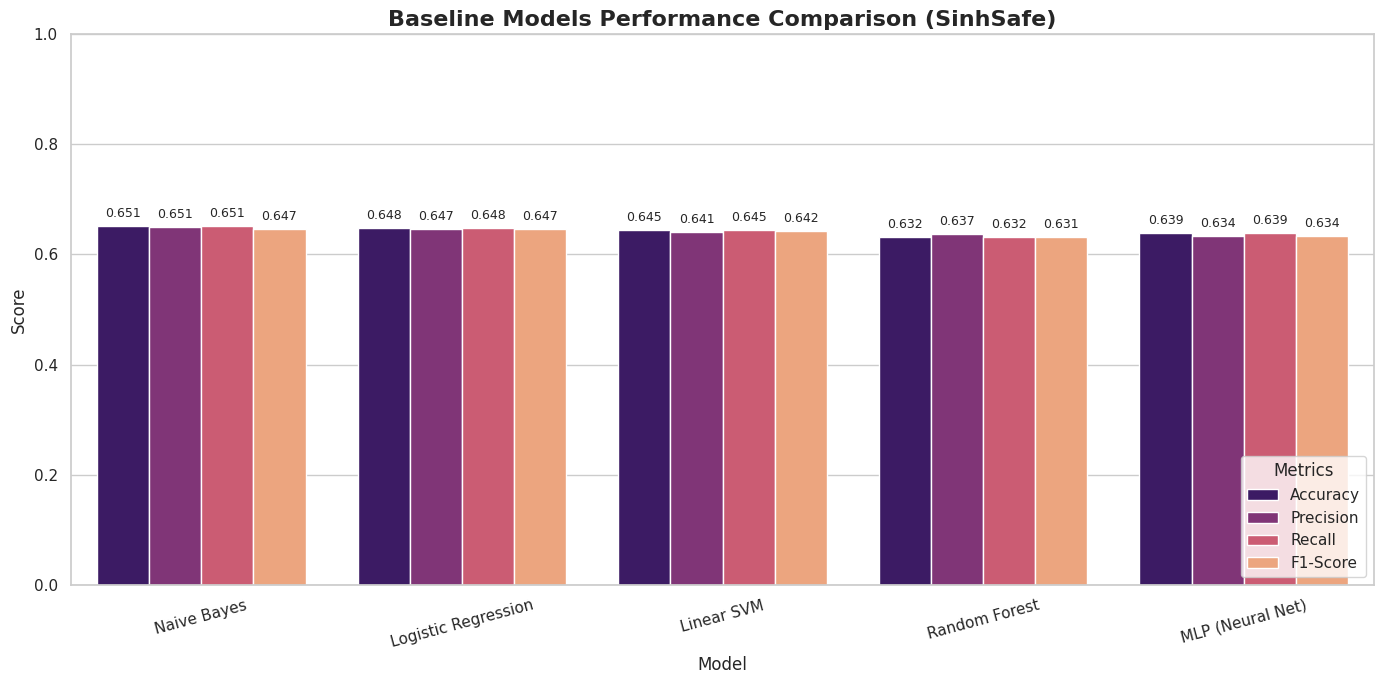

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# --- Configuration ---
DATA_DIR = "/kaggle/input/fyp-data/data/processed_ground_truth"
N_FOLDS = 5 

# --- 1. Load Data ---
def load_raw_data():
    paths = {
        "harass": "processed_consolidated_harassment.xlsx",
        "offen": "processed_consolidated_offensive.xlsx",
        "norm": "processed_consolidated_normal.xlsx"
    }
    found = {}
    for k, v in paths.items():
        p = os.path.join(DATA_DIR, v)
        if not os.path.exists(p):
            for root, _, files in os.walk("/kaggle/input"):
                if v in files: p = os.path.join(root, v)
        found[k] = p

    df_h = pd.read_excel(found["harass"])
    df_o = pd.read_excel(found["offen"])
    df_n = pd.read_excel(found["norm"])
    
    df_n['label'], df_o['label'], df_h['label'] = 0, 1, 2
    df = pd.concat([df_h, df_o, df_n], ignore_index=True)
    df = df[['cleaned_text', 'label']].dropna()
    df.rename(columns={'cleaned_text': 'text'}, inplace=True)
    df['text'] = df['text'].astype(str)
    return df

print("📂 Loading data...")
df = load_raw_data()

# --- 2. Define 5 Baseline Models ---
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=50, early_stopping=True, random_state=42)
}

# --- 3. 5-Fold Cross Validation ---
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Store results for all 4 metrics
results = {name: {'acc': [], 'prec': [], 'rec': [], 'f1': []} for name in models.keys()}

print(f"\n🚀 Starting {N_FOLDS}-Fold CV Baseline Testing...")

for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label'])):
    print(f"\n--- FOLD {fold + 1} ---")
    
    train_text, val_text = df.iloc[train_idx]['text'], df.iloc[val_idx]['text']
    y_train, y_val = df.iloc[train_idx]['label'], df.iloc[val_idx]['label']
    
    # Text Vectorization (TF-IDF)
    vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))
    X_train = vectorizer.fit_transform(train_text)
    X_val = vectorizer.transform(val_text)
    
    # Train and Evaluate each model
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        
        acc = accuracy_score(y_val, preds)
        prec, rec, f1, _ = precision_recall_fscore_support(y_val, preds, average='weighted', zero_division=0)
        
        results[name]['acc'].append(acc)
        results[name]['prec'].append(prec)
        results[name]['rec'].append(rec)
        results[name]['f1'].append(f1)

# --- 4. Summarize and Export Results ---
print("\n" + "="*70)
print(f"🏆 FINAL BASELINE CV RESULTS ({N_FOLDS}-Fold Averages)")
print("="*70)
print(f"{'Model':<25} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 70)

final_data = []
for name in models.keys():
    avg_acc = np.mean(results[name]['acc'])
    avg_prec = np.mean(results[name]['prec'])
    avg_rec = np.mean(results[name]['rec'])
    avg_f1 = np.mean(results[name]['f1'])
    
    print(f"{name:<25} | {avg_acc:<10.4f} | {avg_prec:<10.4f} | {avg_rec:<10.4f} | {avg_f1:<10.4f}")
    final_data.append({
        'Model': name, 
        'Accuracy': avg_acc, 
        'Precision': avg_prec, 
        'Recall': avg_rec,
        'F1-Score': avg_f1
    })

# Save to CSV for your Thesis
results_df = pd.DataFrame(final_data)
results_df.to_csv('/kaggle/working/baseline_comparison.csv', index=False)
print("\n✅ Results saved to 'baseline_comparison.csv'")

# --- 5. Generate Comparison Chart for Thesis ---
# Melting the dataframe to plot all metrics side-by-side
df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Model", y="Score", hue="Metric", data=df_melted, palette="magma")

plt.title('Baseline Models Performance Comparison (SinhSafe)', fontsize=16, fontweight='bold')
plt.ylim(0, 1.0)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.legend(loc='lower right', title="Metrics")

# Add numbers on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/baseline_chart.png', dpi=300)
print("✅ Chart saved to 'baseline_chart.png'")